# 03. Exploratory Data Analysis (EDA)
**Project:** Logistics & Delivery Delays Analysis (Olist)

## Objective
Explore the cleaned dataset to surface operational patterns, geographic bottlenecks, seller-level accountability, and customer satisfaction drivers. All findings feed directly into four Tableau dashboards tailored to specific stakeholder decision needs.


## 1. Setup and Loading Data
**Why:** Standard environment setup. matplotlib Agg backend ensures plots render consistently even in headless environments.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

PATH_CLEANED = "../data/processed/olist_cleaned_data.csv"

df = pd.read_csv(PATH_CLEANED)

date_columns = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date'
]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Core time features
df['order_year']    = df['order_purchase_timestamp'].dt.year
df['order_quarter'] = df['order_purchase_timestamp'].dt.to_period('Q').astype(str)
df['order_month']   = df['order_purchase_timestamp'].dt.to_period('M')

print(f"Dataset loaded. Shape: {df.shape}")
print(f"Year range: {df['order_year'].min()} – {df['order_year'].max()}")
df.head()


Dataset loaded. Shape: (109657, 46)
Year range: 2016 – 2018


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_lng,actual_delivery_days,estimated_delivery_days,delivery_delay,is_late,haversine_distance_km,shipping_route,order_year,order_quarter,order_month
0,e2144124f98f3bf46939bc5183104041,bd0342f59a3b8ddc416bd048b2b5d0fb,delivered,2016-10-06 20:06:26,2016-10-08 11:00:24,2016-10-12 11:00:25,2016-10-15 11:00:25,2016-11-28,1.0,8d3995daf4103cf13ff5400bf66c1587,...,-43.067427,8.0,52,-44.0,False,175.638012,RJ -> RJ,2016,2016Q4,2016-10
1,9aa3197e4887919fde0307fc23601d7a,31a4ecf0bd3ea9436b7132bac1a1bdb3,delivered,2016-10-06 13:16:56,2016-10-06 16:06:59,2016-10-14 18:08:17,2016-10-17 19:08:17,2016-11-28,1.0,1949890685a12526806e9463ba1a3964,...,-46.479397,11.0,52,-41.0,False,16.507936,SP -> SP,2016,2016Q4,2016-10
2,b8b9d7046c083150cb5360b83a8ebb51,ec271753df25bad1135a375ed6d7f113,delivered,2016-10-06 12:51:54,2016-10-06 16:05:19,2016-10-15 12:24:17,2016-10-18 13:24:17,2016-11-28,1.0,12715d8bb61f9c2c26219377d9737584,...,-46.567468,12.0,52,-40.0,False,344.196063,SP -> SP,2016,2016Q4,2016-10
3,5204d67853f827d1ee32810bf8f2d6c2,3dc7eb6da6c008460353d9a171e8fe6d,delivered,2016-10-04 17:25:09,2016-10-06 15:45:42,2016-10-10 15:45:44,2016-10-13 15:45:44,2016-11-28,1.0,b6f134ff2933bb0ee1f36e2865f21a91,...,-45.259769,8.0,54,-46.0,False,263.681718,MG -> SP,2016,2016Q4,2016-10
4,d3a84031db6c5de813d5a3a3489712ca,a5bda6def3f77258ca2027b7d4a384e9,delivered,2016-10-09 23:25:13,2016-10-10 11:03:08,2016-10-14 11:03:10,2016-10-14 11:03:10,2016-11-30,2.0,2d78dc9b1f4a5d1ceb28287b82d85b86,...,-48.829744,4.0,51,-47.0,False,298.050499,SP -> SP,2016,2016Q4,2016-10


## 2. D1 — Executive Pulse
**Feeds Dashboard 1 (CEO / Executive Overview)**

**Why:** Senior stakeholders need a single-page health check. They do not want rows — they want headline KPIs and directional trends. We calculate the exact metrics required:
- Overall late delivery rate and its Year-over-Year direction
- Quarterly order volume affected by delays
- Average delay days over time


In [54]:
# Key headline KPI
overall_late_pct = df['is_late'].mean() * 100
print(f"Headline KPI: {overall_late_pct:.2f}% of all delivered orders arrived late.")


Headline KPI: 6.96% of all delivered orders arrived late.


In [55]:
# Year-over-Year late rate — data-driven, reporting what the data shows
yoy = df.groupby('order_year').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay_days=('delivery_delay', 'mean')
).reset_index()
yoy['late_rate_pct'] = (yoy['late_orders'] / yoy['total_orders'] * 100).round(2)
yoy['avg_delay_days'] = yoy['avg_delay_days'].round(2)

print("Year-over-Year Performance:")
print(yoy.to_string(index=False))


Year-over-Year Performance:
 order_year  total_orders  late_orders  avg_delay_days  late_rate_pct
       2016           310            0          -36.73           0.00
       2017         49319         2784          -12.18           5.64
       2018         60028         4843          -11.18           8.07


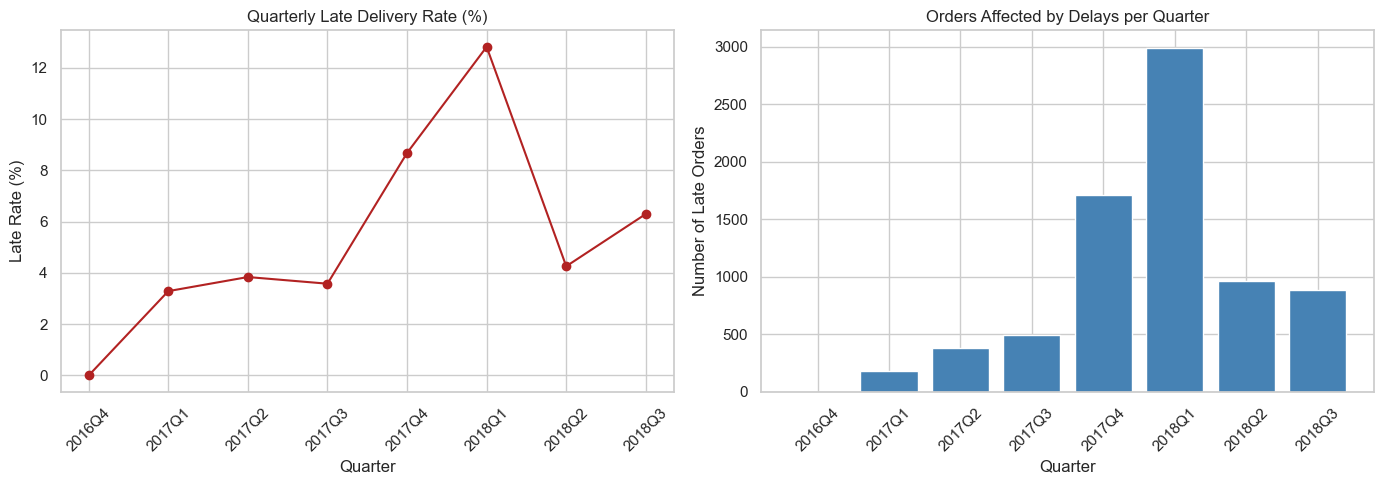

In [56]:
# Quarterly trend — total orders affected by delays per quarter
quarterly = df.groupby('order_quarter').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay_days=('delivery_delay', 'mean')
).reset_index()
quarterly['late_rate_pct'] = (quarterly['late_orders'] / quarterly['total_orders'] * 100).round(2)
quarterly = quarterly[quarterly['total_orders'] > 100]  # Remove low-volume inception quarters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(quarterly['order_quarter'], quarterly['late_rate_pct'], marker='o', color='firebrick')
axes[0].set_title('Quarterly Late Delivery Rate (%)')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Late Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(quarterly['order_quarter'], quarterly['late_orders'], color='steelblue')
axes[1].set_title('Orders Affected by Delays per Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Number of Late Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


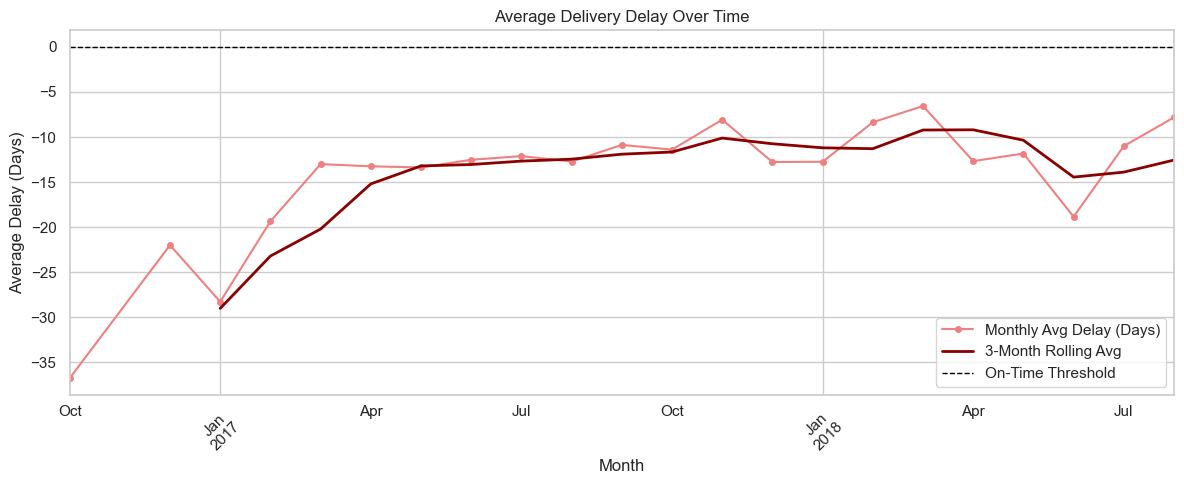

In [57]:
# Average delay in days over time (3-month rolling average)
monthly_avg_delay = df.groupby('order_month')['delivery_delay'].mean()
rolling_avg = monthly_avg_delay.rolling(window=3).mean()

plt.figure(figsize=(12, 5))
monthly_avg_delay.plot(label='Monthly Avg Delay (Days)', color='lightcoral', marker='o', markersize=4)
rolling_avg.plot(label='3-Month Rolling Avg', color='darkred', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On-Time Threshold')
plt.title('Average Delivery Delay Over Time')
plt.xlabel('Month')
plt.ylabel('Average Delay (Days)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. D2 — Geographic Risk Monitor
**Feeds Dashboard 2 (Operations Team / State Choropleth)**

**Why:** Operations managers need to direct resources toward specific geographic regions. We compute delay performance at two levels — state and city — and identify the top shipping routes purely from the data. No assumptions are made about outcomes before analysis.


In [58]:
# Haversine Distance (safe — skips rows with missing coordinates)
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between seller and customer coordinates."""
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * np.arcsin(np.sqrt(a)) * 6371

mask = df[['seller_lat', 'seller_lng', 'customer_lat', 'customer_lng']].notnull().all(axis=1)
df['haversine_distance_km'] = np.nan
df.loc[mask, 'haversine_distance_km'] = haversine(
    df.loc[mask, 'seller_lat'], df.loc[mask, 'seller_lng'],
    df.loc[mask, 'customer_lat'], df.loc[mask, 'customer_lng']
)
print(f"Distance computed for {df['haversine_distance_km'].notnull().sum()} orders.")


Distance computed for 109126 orders.


In [59]:
# State-level aggregation — all 22 states, sorted by avg_delay
state_stats = df.groupby('seller_state').agg(
    total_orders=('order_id', 'count'),
    avg_delay=('delivery_delay', 'mean'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100),
    avg_distance_km=('haversine_distance_km', 'mean')
).reset_index().sort_values('avg_delay', ascending=False).round(2)

print("All Seller States ranked by Average Delay:")
print(state_stats.to_string(index=False))


All Seller States ranked by Average Delay:
seller_state  total_orders  avg_delay  late_rate_pct  avg_distance_km
          AM             2      -5.00           0.00          2104.60
          PA             8     -10.50          12.50           672.28
          MA           401     -10.73          21.20          1949.05
          SP         78238     -10.95           7.54           537.00
          RJ          4659     -12.20           7.23           575.33
          BA           621     -12.53           4.83          1157.06
          DF           880     -12.71           6.25           844.65
          RN            56     -12.77          10.71           977.21
          ES           362     -13.09           5.52           804.44
          MG          8553     -13.26           4.69           597.53
          GO           506     -13.94           3.16           839.96
          SC          3975     -13.97           4.93           735.68
          PR          8433     -13.98          

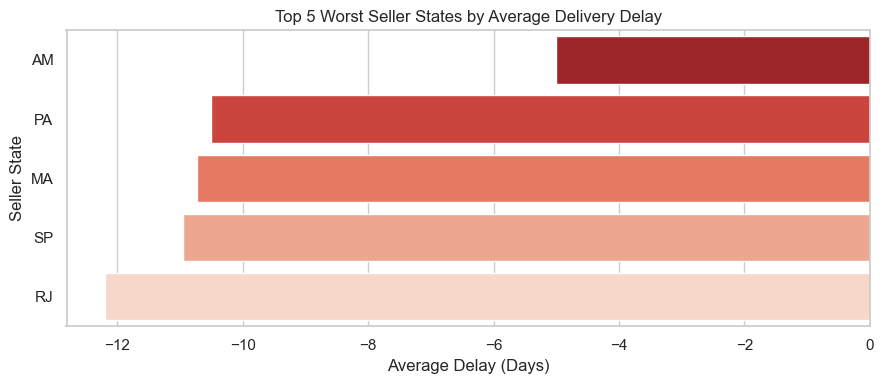

Top 5 Worst States:
seller_state  avg_delay  late_rate_pct  total_orders
          AM      -5.00           0.00             2
          PA     -10.50          12.50             8
          MA     -10.73          21.20           401
          SP     -10.95           7.54         78238
          RJ     -12.20           7.23          4659


In [60]:
# Top 5 worst-performing seller states (data-driven)
top5_worst = state_stats.head(5)

plt.figure(figsize=(9, 4))
sns.barplot(data=top5_worst, x='avg_delay', y='seller_state', palette='Reds_r')
plt.title('Top 5 Worst Seller States by Average Delivery Delay')
plt.xlabel('Average Delay (Days)')
plt.ylabel('Seller State')
plt.tight_layout()
plt.show()

print("Top 5 Worst States:")
print(top5_worst[['seller_state', 'avg_delay', 'late_rate_pct', 'total_orders']].to_string(index=False))


In [61]:
# Top shipping routes by volume of late orders — data-driven ranking
df['shipping_route'] = df['seller_state'] + ' -> ' + df['customer_state']

route_stats = df.groupby('shipping_route').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay=('delivery_delay', 'mean'),
    avg_distance_km=('haversine_distance_km', 'mean')
).reset_index()
route_stats['late_rate_pct'] = (route_stats['late_orders'] / route_stats['total_orders'] * 100).round(2)
route_stats = route_stats.sort_values('late_orders', ascending=False).head(10)

print("Top 10 Routes by Volume of Late Orders (data-driven):")
print(route_stats[['shipping_route', 'total_orders', 'late_orders', 'late_rate_pct', 'avg_delay']].to_string(index=False))


Top 10 Routes by Volume of Late Orders (data-driven):
shipping_route  total_orders  late_orders  late_rate_pct  avg_delay
      SP -> SP         35369         1896           5.36  -9.727106
      SP -> RJ          9276         1209          13.03 -11.207201
      SP -> MG          8558          477           5.57 -12.268871
      SP -> BA          2599          340          13.08 -10.856098
      SP -> SC          2699          264           9.78 -10.596888
      SP -> RS          4108          255           6.21 -14.248783
      SP -> ES          1614          212          13.14  -9.298017
      SP -> PR          3602          169           4.69 -12.732926
      SP -> CE          1071          144          13.45 -11.458450
      PR -> RJ          1099          123          11.19 -13.840764


In [62]:
# Top seller cities by avg delay — minimum 50 orders for statistical validity
city_stats = df.groupby(['seller_city', 'seller_state']).agg(
    total_orders=('order_id', 'count'),
    avg_delay=('delivery_delay', 'mean'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100)
).reset_index()

# Minimum 50 orders threshold — prevents cities with 1-2 orders skewing results
city_stats = city_stats[city_stats['total_orders'] >= 50].sort_values('avg_delay', ascending=False)

print("Top 10 Seller Cities by Average Delay (min. 50 orders):")
print(city_stats.head(10)[['seller_city', 'seller_state', 'avg_delay', 'late_rate_pct', 'total_orders']].to_string(index=False))


Top 10 Seller Cities by Average Delay (min. 50 orders):
        seller_city seller_state  avg_delay  late_rate_pct  total_orders
santana de parnaiba           SP  -7.006369      15.923567           157
         sao  paulo           SP  -7.134615      21.153846            52
            dracena           SP  -7.919492       8.474576           236
 sao joao de meriti           RJ  -8.460000      14.000000            50
        hortolandia           SP  -8.598214       7.440476           336
  laranjal paulista           SP  -8.736842      12.550607           247
     sao paulo - sp           SP  -9.165049      14.563107           103
sao jose dos campos           SP  -9.236292      10.835509           766
    pocos de caldas           MG  -9.306306       6.306306           111
            atibaia           SP  -9.442975       8.760331           605


## 4. D3 — Seller Performance Scorecard
**Feeds Dashboard 3 (Seller Management)**

**Why:** Identifying individual seller accountability requires careful statistical design. A seller with 1 late order in 2 total orders has a 50% delay rate — but that is meaningless noise. We apply a **minimum order threshold of 10 orders** before including any seller in performance rankings. This is a critical methodological requirement — without it, seller-level analysis becomes statistically invalid.


In [63]:
# Aggregate by seller_id — minimum 10 orders threshold (prevents bias from low-volume sellers)
MIN_ORDERS = 10

seller_stats = df.groupby('seller_id').agg(
    seller_state=('seller_state', 'first'),
    seller_city=('seller_city', 'first'),
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay=('delivery_delay', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()

seller_stats['delay_rate_pct'] = (seller_stats['late_orders'] / seller_stats['total_orders'] * 100).round(2)

# Apply threshold
seller_stats = seller_stats[seller_stats['total_orders'] >= MIN_ORDERS].copy()
seller_stats = seller_stats.round(2)

print(f"Sellers with >= {MIN_ORDERS} orders: {len(seller_stats)}")
print(f"Sellers with >13% delay rate  : {(seller_stats['delay_rate_pct'] > 13).sum()}")


Sellers with >= 10 orders: 1338
Sellers with >13% delay rate  : 202


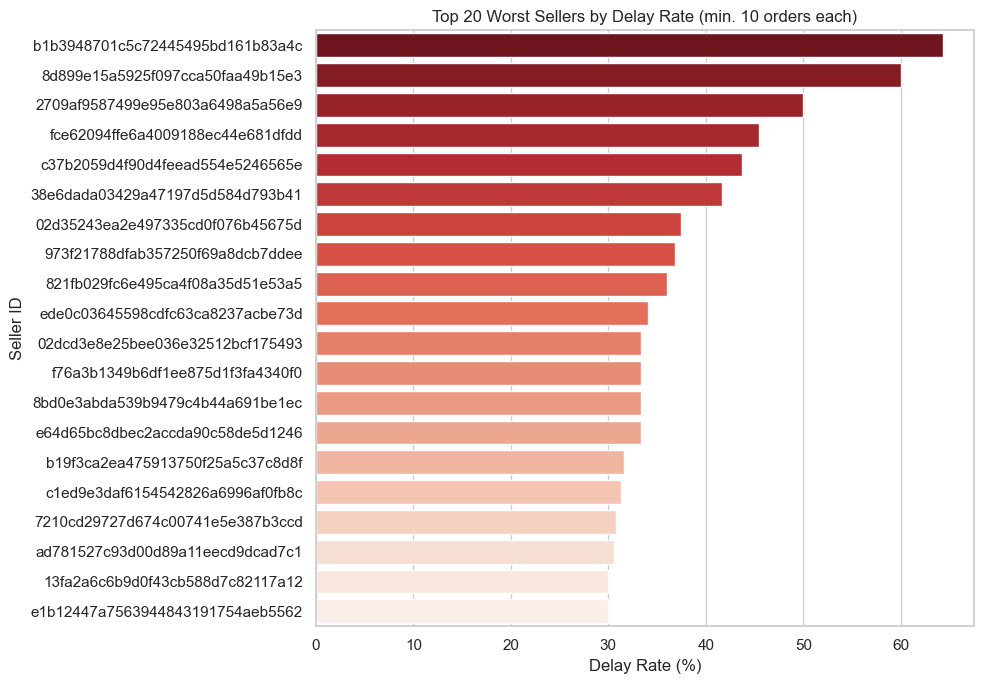

In [64]:
# Top 20 worst sellers by delay rate
top20_sellers = seller_stats.sort_values('delay_rate_pct', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top20_sellers, x='delay_rate_pct', y='seller_id', palette='Reds_r')
plt.title(f'Top 20 Worst Sellers by Delay Rate (min. {MIN_ORDERS} orders each)')
plt.xlabel('Delay Rate (%)')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()


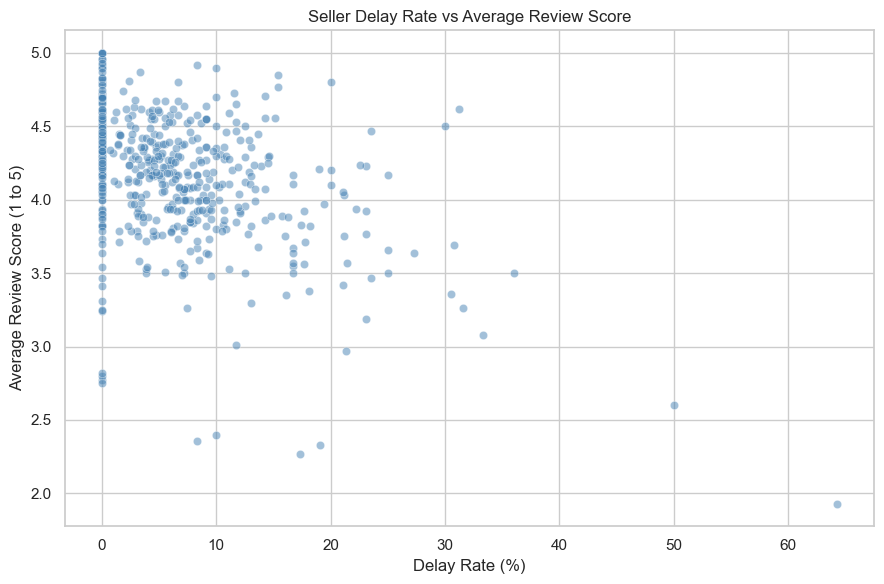

In [65]:
# Seller delay rate vs avg review score — scatter plot (data-driven correlation)
sample_sellers = seller_stats.sample(min(500, len(seller_stats)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample_sellers, x='delay_rate_pct', y='avg_review_score',
                alpha=0.5, color='steelblue')
plt.title('Seller Delay Rate vs Average Review Score')
plt.xlabel('Delay Rate (%)')
plt.ylabel('Average Review Score (1 to 5)')
plt.tight_layout()
plt.show()


## 5. D4 — Customer Experience Impact
**Feeds Dashboard 4 (Marketing / CX Teams)**

**Why:** Customer satisfaction is the end-state consequence of all upstream logistics failures. We analyze year-over-year deterioration in review quality, validate the correlation between delay severity and review score, and map where the worst customer experiences are concentrated geographically.


In [66]:
# Bad review rate — defined as review_score <= 2 (1 / 2 -star reviews)
df['is_bad_review'] = df['review_score'] <= 2

bad_review_yoy = df.groupby('order_year').agg(
    total_reviews=('review_score', 'count'),
    bad_reviews=('is_bad_review', 'sum')
).reset_index()
bad_review_yoy['bad_review_rate_pct'] = (bad_review_yoy['bad_reviews'] / bad_review_yoy['total_reviews'] * 100).round(2)

print("Year-over-Year Bad Review Rate (1-star):")
print(bad_review_yoy.to_string(index=False))


Year-over-Year Bad Review Rate (1-star):
 order_year  total_reviews  bad_reviews  bad_review_rate_pct
       2016            307           60                19.54
       2017          48912         6656                13.61
       2018          59637         9080                15.23


Review Score Comparison:
Is Late  Avg Review Score  Median Review Score  Order Count
On Time          4.210143                  5.0       101393
   Late          2.480370                  2.0         7463


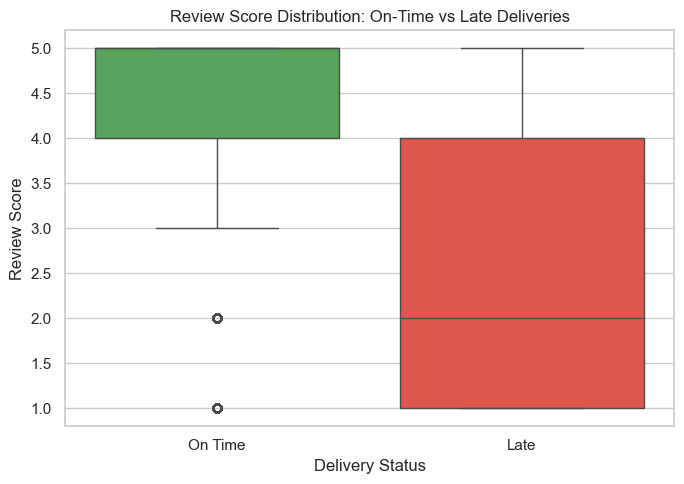

In [67]:
# On-time vs Late average review score comparison
review_compare = df.groupby('is_late')['review_score'].agg(['mean', 'median', 'count']).reset_index()
review_compare.columns = ['Is Late', 'Avg Review Score', 'Median Review Score', 'Order Count']
review_compare['Is Late'] = review_compare['Is Late'].map({True: 'Late', False: 'On Time'})

print("Review Score Comparison:")
print(review_compare.to_string(index=False))

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_late', y='review_score', palette=['#4CAF50', '#F44336'])
plt.xticks([0, 1], ['On Time', 'Late'])
plt.title('Review Score Distribution: On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Review Score')
plt.tight_layout()
plt.show()


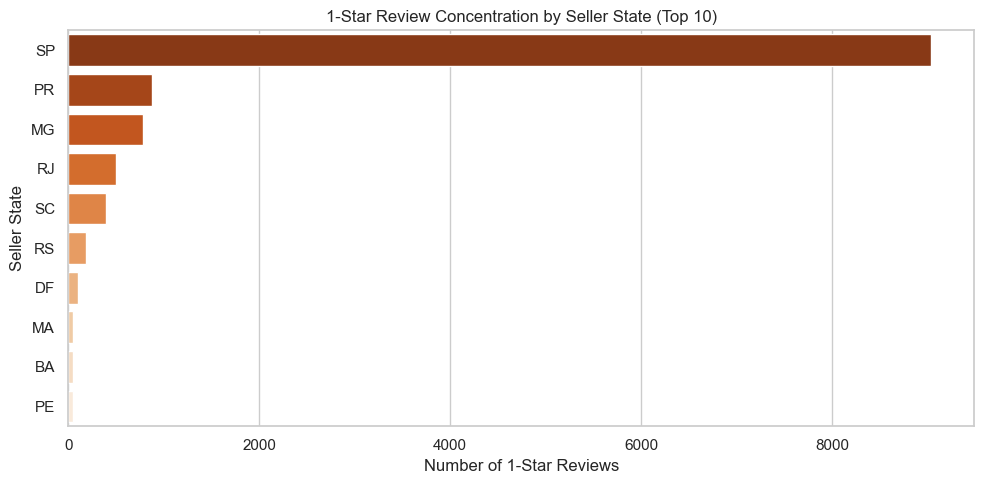

In [68]:
# 1-star review concentration by seller state
one_star_state = df[df['review_score'] == 1].groupby('seller_state').agg(
    one_star_reviews=('review_score', 'count'),
    total_orders=('order_id', 'count')
).reset_index()
one_star_state['one_star_rate_pct'] = (one_star_state['one_star_reviews'] / one_star_state['total_orders'] * 100).round(2)
one_star_state = one_star_state.sort_values('one_star_reviews', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=one_star_state.head(10), x='one_star_reviews', y='seller_state', palette='Oranges_r')
plt.title('1-Star Review Concentration by Seller State (Top 10)')
plt.xlabel('Number of 1-Star Reviews')
plt.ylabel('Seller State')
plt.tight_layout()
plt.show()


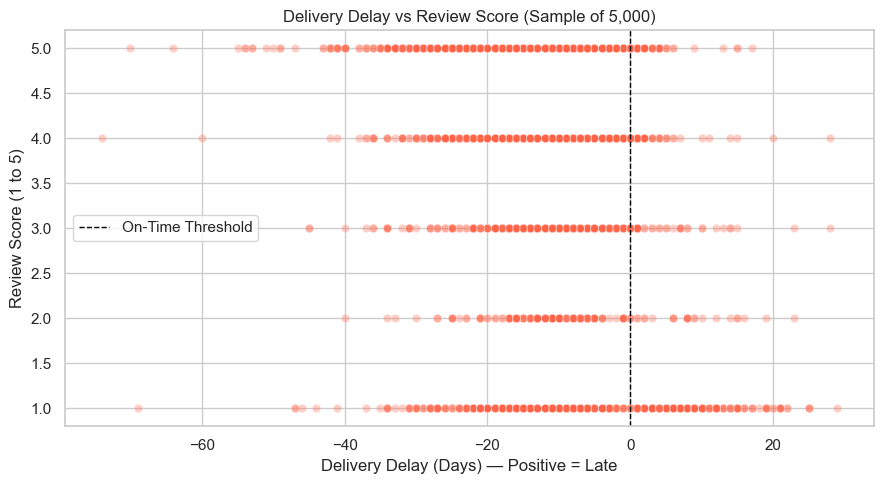

In [69]:
# Delivery delay vs review score — scatter (confirmed correlation, not assumed)
scatter_df = df[['delivery_delay', 'review_score']].dropna().sample(n=5000, random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=scatter_df, x='delivery_delay', y='review_score', alpha=0.3, color='tomato')
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='On-Time Threshold')
plt.title('Delivery Delay vs Review Score (Sample of 5,000)')
plt.xlabel('Delivery Delay (Days) — Positive = Late')
plt.ylabel('Review Score (1 to 5)')
plt.legend()
plt.tight_layout()
plt.show()
